# INTRODUCTION
### Name: Gabriel Lau, Eli Gillam
# Course: DATA 200

In this data set we will be explore data for AirBNB Lisitngs. 

Research Question: Which ammenities/description patterns are linked to higher nightly price ?



In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv('Toronto_Listing.csv')
# Display the first few rows of the dataset
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1419,Beautiful home in amazing area!,1565,Alexandra,NaN,Little Portugal,43.64590,-79.42423,Entire home/apt,NaN,28,6,2017-08-07,0.05,1,0,0,NaN
1,8077,Downtown Harbourfront Private Room,22795,Kathie & Larry,NaN,Waterfront Communities-The Island,43.64080,-79.37673,Private room,NaN,180,167,2013-08-27,0.85,2,0,0,NaN
2,26654,"World Class @ CN Tower, convention centre, The...",113345,Adela,NaN,Waterfront Communities-The Island,43.64608,-79.39032,Entire home/apt,133.0,28,45,2025-02-01,0.25,3,140,2,NaN


In [2]:
# Display basic information about the dataset
df.info()
# Display summary statistics for numerical columns
df.describe()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21468 entries, 0 to 21467
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              21468 non-null  int64  
 1   name                            21468 non-null  object 
 2   host_id                         21468 non-null  int64  
 3   host_name                       21452 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   21468 non-null  object 
 6   latitude                        21468 non-null  float64
 7   longitude                       21468 non-null  float64
 8   room_type                       21468 non-null  object 
 9   price                           15809 non-null  float64
 10  minimum_nights                  21468 non-null  int64  
 11  number_of_reviews               21468 non-null  int64  
 12  last_review                     

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.146800e+04,2.146800e+04,0.0,21468.000000,21468.000000,15809.000000,21468.000000,21468.000000,16615.000000,21468.000000,21468.000000,21468.000000
mean,7.136639e+17,2.496620e+08,NaN,43.684376,-79.398019,176.304763,25.356437,30.349637,1.372491,4.803522,177.850475,7.507639
std,5.940509e+17,2.300333e+08,NaN,0.050166,0.071027,308.294008,39.677861,61.219810,1.785610,11.818997,137.515470,14.400383
min,1.419000e+03,1.565000e+03,NaN,43.586470,-79.637273,12.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.571915e+07,3.832562e+07,NaN,43.646413,-79.430210,76.000000,3.000000,1.000000,0.180000,1.000000,35.000000,0.000000
50%,8.601208e+17,1.675228e+08,NaN,43.665225,-79.397431,125.000000,28.000000,7.000000,0.590000,1.000000,178.000000,1.000000
75%,1.257953e+18,4.717031e+08,NaN,43.710988,-79.374425,201.000000,28.000000,33.000000,1.990000,3.000000,318.000000,7.000000
max,1.551252e+18,7.283373e+08,NaN,43.837740,-79.121330,11185.000000,1125.000000,1287.000000,34.050000,121.000000,365.000000,395.000000


# Interpretation:

Size of our dataset: 21 468 different lisitngs with 18 different variables

From our df.info() price has 15 809 non-null values, which means 5 659 listings are missing a price within our data, reviews_per_month and last_review also have missing values. License has many missing values, however neighbourhood group has 0 non-null values. We will have to celan our data before we can build a model to predict our research question. 


In [3]:
# 2. Data Cleaning and Preprocessing
# Create a summary DataFrame to show data types, missing value percentages, and unique value counts
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "missing_values": df.isnull().sum()
}).sort_values("missing_values", ascending=False)
print(summary)

# Check for column names and dataset shape
print("Shape:", df.shape)
print("Columns:", list(df.columns))

                                  dtype  n_unique  missing_values
neighbourhood_group             float64         0           21468
license                          object      8119           11074
price                           float64       787            5659
reviews_per_month               float64       872            4853
last_review                      object      2411            4853
host_name                        object      7441              16
name                             object     20997               0
id                                int64     21468               0
neighbourhood                    object       140               0
host_id                           int64     14379               0
room_type                        object         4               0
longitude                       float64     16351               0
latitude                        float64     14753               0
number_of_reviews                 int64       440               0
minimum_ni

# Missing values analysis:

- From analysis we can see two key columns neighnourhood_group and price contain missing values. Since neighbourhood group contains no usable information and does not contribute to explaining variation 
in price, it is removed from the dataset since misisng values = number of observations.  

- The price variable, which serves as the dependent variable in our analysis, contains missing values. Because price is essential for modelling and cannot be meaningfully imputed in this context, we remove all rows where price is missing.



In [4]:
# From the summary table above, we can see that there are 2 columns with missing values: 'neighbourhood_group' and 'price'.
# In order to process the data, we need to handle these missing values. Since 'neighbourhood_group' is null for all rows, it does not provide any useful information and can be dropped. 
# For the 'price' column, we will remove any rows where the price is NaN, as these rows cannot be used for analysis or modeling.
# Neighbourhood_Group is null, so we can drop it
df_clean = df.drop(columns=["neighbourhood_group"], errors="ignore")
# Remove data that the price is NaN
df_clean = df_clean.dropna(subset=["price"]).reset_index(drop=True)
# df_clean.info()
# Convert date and handle "Reviews per month" column
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")
# If no last_review, treat reviews_per_month as 0
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)
#Convert last_review to a binary indicator of whether the listing has ever been reviewed
df_clean["has_review"] = (df_clean["number_of_reviews"] > 0).astype(int)
# Create a license indicator
df_clean["license_present"] = df_clean["license"].notna().astype(int)
# After dropping the 'neighbourhood_group' column and removing rows with NaN values in the 'price' column, we can see that there are no missing values left in the dataset. The shape of the dataset has also changed, indicating that some rows have been removed.
# However, there is some outliers for the price column, which may affect the analysis and modeling. We will handle these outliers in the next step.
df_clean["price"].describe(percentiles=[0.95, 0.99, 0.995])
# Reset the order of the id column after dropping rows
df_clean = df_clean.drop_duplicates(subset="id").reset_index(drop=True)
# Sanity Check to identify potential data issues
checks = {
    "price <= 0": (df_clean["price"] <= 0).sum(),
    "minimum_nights <= 0": (df_clean["minimum_nights"] <= 0).sum(),
    "availability_365 outside [0,365]": ((df_clean["availability_365"] < 0) | (df_clean["availability_365"] > 365)).sum(),
    "host_listings_count < 1": (df_clean["calculated_host_listings_count"] < 1).sum(),
    "reviews_ltm > total_reviews": (df_clean["number_of_reviews_ltm"] > df_clean["number_of_reviews"]).sum(),
}

print("Sanity Check Results:")
for check, count in checks.items():
    print(f"{check}: {count} issues found")
# df_clean.head(3)

Sanity Check Results:
price <= 0: 0 issues found
minimum_nights <= 0: 0 issues found
availability_365 outside [0,365]: 0 issues found
host_listings_count < 1: 0 issues found
reviews_ltm > total_reviews: 0 issues found


# Interpretation/What we did

- Neighnourhood group was removed, since usuable information, rows with missing price were removed since price is our dependent variable in our analysis. 
- reviews_per_month missing values were replaced with 0, which represents listings with no review activity
- last_review was converted to date time to ensure correct data type. 
- Binary indicator has_review was created to capture whether a lsiting has ever recieved a review, the same was done for license_present



In [5]:
# 3. Exploratory Data Analysis (EDA)
# ---------- Minimal feature prep ----------
df_clean["log_price"] = np.log(df_clean["price"])

df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)
df_clean["log_reviews_pm"] = np.log1p(df_clean["reviews_per_month"])

df_clean["number_of_reviews_ltm"] = df_clean["number_of_reviews_ltm"].fillna(0)
df_clean["log_reviews_ltm"] = np.log1p(df_clean["number_of_reviews_ltm"])

df_clean["license_present"] = df_clean["license"].notna().astype(int)

df_clean["host_portfolio_bin"] = pd.cut(
    df_clean["calculated_host_listings_count"],
    bins=[0, 1, 3, 10, np.inf],
    labels=["1 listing", "2–3 listings", "4–10 listings", "11+ listings"]
)

# Downtown distance (Toronto City Hall)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

DOWNTOWN_LAT, DOWNTOWN_LON = 43.6532, -79.3832
df_clean["dist_downtown_km"] = haversine_km(df_clean["latitude"], df_clean["longitude"], DOWNTOWN_LAT, DOWNTOWN_LON)

# Top neighbourhoods (avoid 100+ categories)
TOP_K = 10
top_neigh = df_clean["neighbourhood"].value_counts().head(TOP_K).index
df_clean["neighbourhood_top"] = np.where(df_clean["neighbourhood"].isin(top_neigh), df_clean["neighbourhood"], "Other")

# Interpretation

To improve model performance and interpretability, several cleaning steps were performed. Skewed continuous variables such as price and review counts were log-transformed to reduce the influence of extreme values. A binary indicator was created to capture license presence. Host listing counts were grouped into portfolio size categories to account for non-linear scale effects. This feature engineering method is used in courses like ST362 and ST473 to enable our data is prepped and ready for model building. From above, our downtown distance code is implemmented to predict if the distance from each AirBNB to Toronto City hall has an affect on price, which in turn will help us answer our research question of if ammenties/description of AirBNB affect reviews. The Limitation of this example however is we are using only one tourist destination in Tornto rather than multiple conditions. 


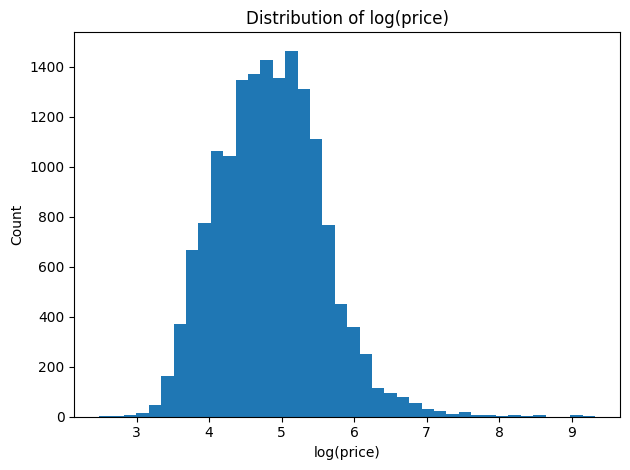

C:\Users\lkwga\AppData\Local\Temp\ipykernel_42372\4245942461.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


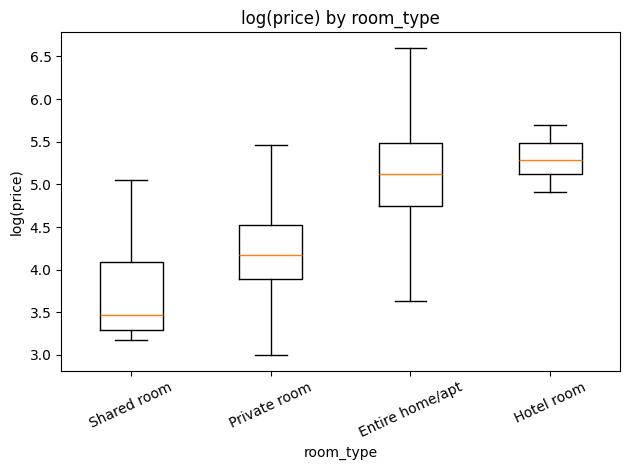

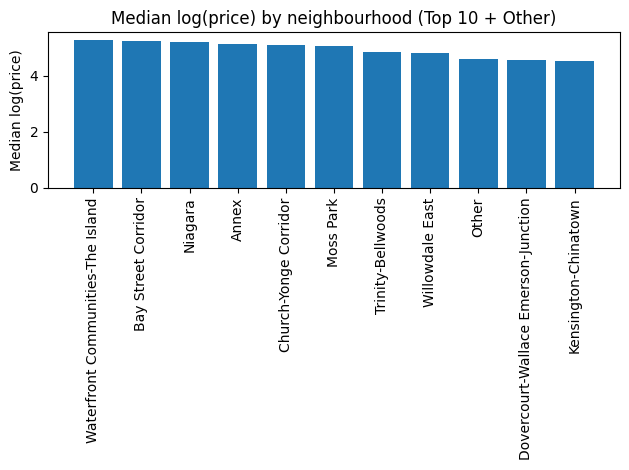

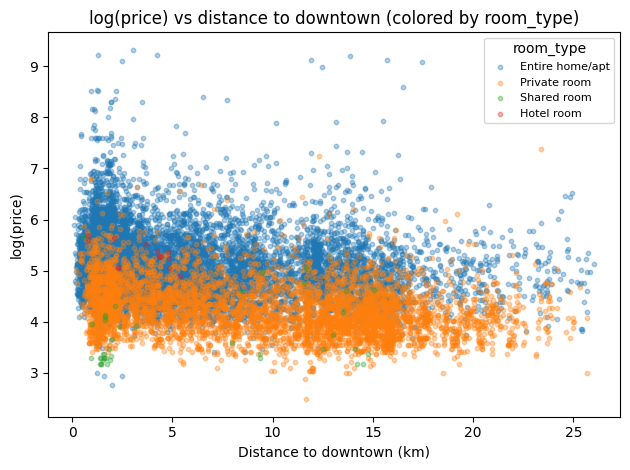

In [6]:
# 1) Distribution of log(price)
plt.figure()
plt.hist(df_clean["log_price"].dropna(), bins=40)
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.title("Distribution of log(price)")
plt.tight_layout()
plt.show()

# 2) log(price) by room_type
plt.figure()
order = df_clean.groupby("room_type")["log_price"].median().sort_values().index
data = [df_clean.loc[df_clean["room_type"]==rt, "log_price"].dropna() for rt in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.xlabel("room_type")
plt.ylabel("log(price)")
plt.title("log(price) by room_type")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 3) Median log(price) by neighbourhood (Top 10 + Other)
med_nbhd = df_clean.groupby("neighbourhood_top")["log_price"].median().sort_values(ascending=False)
plt.figure()
plt.bar(med_nbhd.index.astype(str), med_nbhd.values)
plt.xticks(rotation=90)
plt.ylabel("Median log(price)")
plt.title(f"Median log(price) by neighbourhood (Top {TOP_K} + Other)")
plt.tight_layout()
plt.show()

# 4) log(price) vs distance to downtown (colored by room_type)
plt.figure()
for rt in df_clean["room_type"].dropna().unique():
    sub = df_clean[df_clean["room_type"] == rt]
    plt.scatter(sub["dist_downtown_km"], sub["log_price"], alpha=0.35, label=str(rt), s=10)
plt.xlabel("Distance to downtown (km)")
plt.ylabel("log(price)")
plt.title("log(price) vs distance to downtown (colored by room_type)")
plt.legend(title="room_type", fontsize=8)
plt.tight_layout()
plt.show()

# Interpreation of Graphs ()

Distribution of log(price) **Histogram**: Roughly bell-shaped, much more symmetric than raw price, slight right tail still exists, but far less extreme use our log price model. 
If we want to study whether amenities/description increase price we need price to behave nicely statistically, therefore log(price) gives us a stable dependent variable. 

**Log Price by Room Type:** The graph shows that shared rooms have the lowest price, followed by private rooms, entire homes, then hotel room being the highest. Room type acts as a baseline for how ammenities would affect higher price. Entire homes have privates kitchens, bathrooms, full spaces and more privacy which reflect a higher price, shared rooms with fewer ammentities reflect lower prices in conclusion this graph highlights listings with more built-in amenities (privacy, full property access) command higher prices.

**Median log(price) by neighbourhood:** The graph shows downtown and waterfront neighborhoods have higher median log(price). This matters because promixity to attractionsm, restaraunts, acts as a strong baseline pricing factor. When examining amenity effects, it will be important to control for geographic variation.

**Log(price) vs Distance to downtown:** Graph shows a clear negative relationship, price decreases as distance increases and entire homes consistently sit above other room types. If we later find that listings with “luxury” in their description are expensive, we must ask: Are they expensive because they’re luxury?
Or because they’re downtown? So if distance is a factor in price, then the ammenties itself don't relatively correlate to higher prices if this is the case.



In [9]:
# Keyword indicators (based on common listing features and amenities) - REGEX 
kw_patterns = {
    "kw_downtown": r"\b(downtown|dt|financial\s*district|city\s*centre|city\s*center)\b",
    "kw_subway": r"\b(subway|metro|ttc|station)\b",
    "kw_parking": r"\b(parking|free\s*parking|garage)\b",
    "kw_waterfront": r"\b(waterfront|lake\s*view|lakeside)\b",
    "kw_luxury": r"\b(luxury|lux|executive|premium)\b",
    "kw_balcony": r"\b(balcony|terrace|patio)\b",
}

for col, pat in kw_patterns.items():
    df_clean[col] = df_clean["name"].str.contains(pat, case=False, regex=True, na=False).astype(int)
by_room = (df_clean.groupby("room_type")
             .agg(
                 n=("id", "size"),
                 median_price=("price", "median"),
                 median_log_price=("log_price", "median"),
                 median_reviews_pm=("reviews_per_month", "median"),
                 median_reviews_ltm=("number_of_reviews_ltm", "median"),
                 share_licensed=("license_present", "mean")
             )
             .sort_values("median_log_price", ascending=False))

by_room.round(3)

by_nbhd = (df_clean.groupby("neighbourhood_top")
             .agg(
                 n=("id","size"),
                 median_price=("price","median"),
                 median_reviews_pm=("reviews_per_month","median"),
                 pct_entire_home=("room_type", lambda s: (s=="Entire home/apt").mean())
             )
             .sort_values(["n","median_price"], ascending=False))

by_nbhd.head(3).round(3)

pivot_price = df_clean.pivot_table(
    index="host_portfolio_bin",
    columns="room_type",
    values="log_price",
    aggfunc="median"
)

pivot_price.round(3)



kw_cols = [c for c in df_clean.columns if c.startswith("kw_")]

uplift_rows = []
for c in kw_cols:
    med_yes = df_clean.loc[df_clean[c]==1, "log_price"].median()
    med_no  = df_clean.loc[df_clean[c]==0, "log_price"].median()
    uplift_rows.append({
        "keyword": c,
        "share_present": df_clean[c].mean(),
        "uplift_log": med_yes - med_no,
        "uplift_pct_approx": (np.exp(med_yes - med_no) - 1) * 100
    })

uplift = pd.DataFrame(uplift_rows).sort_values("uplift_log", ascending=False)
uplift.round(3)

C:\Users\lkwga\AppData\Local\Temp\ipykernel_42372\2704507230.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean[col] = df_clean["name"].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\lkwga\AppData\Local\Temp\ipykernel_42372\2704507230.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean[col] = df_clean["name"].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\lkwga\AppData\Local\Temp\ipykernel_42372\2704507230.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean[col] = df_clean["name"].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\lkwga\AppData\Local\Temp\ipykernel_42372\2704507230.py:12: UserWarning: This pattern is int

,keyword,share_present,uplift_log,uplift_pct_approx
4,kw_luxury,0.071,0.511,66.667
3,kw_waterfront,0.027,0.395,48.387
2,kw_parking,0.125,0.389,47.500
5,kw_balcony,0.032,0.295,34.274
0,kw_downtown,0.159,0.275,31.667
1,kw_subway,0.059,-0.352,-29.687


# Keyword indicators and REGEX Interpretation

- To investigate whether description patterns are reflective with higher nightly prices, keyword indicators were constructed using regular expressions applied to listing titles. Binary variables were created for terms such as luxury, waterfront, parking, balcony, downtown, and subway. For each keyword, the median log(price) of listings containing the term was compared to those that did not, and the difference was converted into an approximate percentage price premium.

- Results indicate that certain descriptive signals are strongly associated with higher prices. Listings mentioning luxury exhibit the largest estimated premium (approximately 67%), followed by “waterfront” and “parking”, both associated with premiums near 50%. Mentions of “balcony” and “downtown” also correspond to meaningful positive price differences. Interestingly, listings referencing “subway” access are associated with lower prices, suggesting that transit-oriented marketing may be more common among mid-range or budget listings.

- These findings suggest that description-based amenities and marketing language are strongly correlated with pricing. However, these associations are descriptive rather than causal. Keywords such as “luxury” or “waterfront” may proxy for other structural characteristics, such as property size, room type, or central location. Therefore, further regression analysis controlling for structural and geographic factors is necessary to isolate the independent pricing effect of these description patterns.


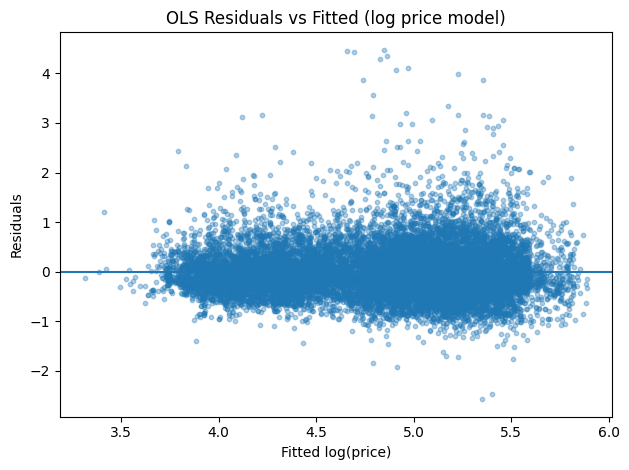

R^2: 0.49  |  Adj R^2: 0.489


In [10]:
# Pick which keyword flags you want (keep it small & meaningful) - keyword pattern
kw_cols = [c for c in df_clean.columns if c.startswith("kw_")]
kw_cols = [c for c in kw_cols if c in ["kw_downtown","kw_subway","kw_parking","kw_waterfront","kw_luxury","kw_balcony"]]  # optional

# Build formula (Top 10 neighbourhoods + Other is more stable than full neighbourhood)
formula_price = "log_price ~ C(room_type) + C(neighbourhood_top) + dist_downtown_km + minimum_nights + availability_365 + C(host_portfolio_bin) + license_present"
if len(kw_cols) > 0:
    formula_price += " + " + " + ".join(kw_cols)

# Fit with robust standard errors (handles heteroskedasticity better)
m_price = smf.ols(formula_price, data=df_clean).fit(cov_type="HC3")

# Compact coefficient table (don’t dump the whole summary unless you want to)
coef = m_price.params
se = m_price.bse
pval = m_price.pvalues

out = (pd.DataFrame({"coef": coef, "se(HC3)": se, "pval": pval})
         .drop(index="Intercept")
         .sort_values("pval")
      )

out.head(3).round(4)

# Only interpret the stuff you actually care about (keywords + host + distance)
focus_terms = kw_cols + ["license_present", "dist_downtown_km"]
focus_terms = [t for t in focus_terms if t in m_price.params.index]

interp_rows = []
for t in focus_terms:
    b = m_price.params[t]
    pct = (np.exp(b) - 1) * 100
    interp_rows.append({"term": t, "coef": b, "approx_%_effect_on_price": pct})

interp = pd.DataFrame(interp_rows).sort_values("approx_%_effect_on_price", ascending=False)
interp.round(3)

plt.figure()
plt.scatter(m_price.fittedvalues, m_price.resid, alpha=0.35, s=10)
plt.axhline(0)
plt.xlabel("Fitted log(price)")
plt.ylabel("Residuals")
plt.title("OLS Residuals vs Fitted (log price model)")
plt.tight_layout()
plt.show()

print("R^2:", round(m_price.rsquared, 3), " |  Adj R^2:", round(m_price.rsquared_adj, 3))



# Model Interpretation

- The regression model explains log(price) using: room types, top neighnourhood categories, distance to downtown, min nights, availability, etc

- Model explains approx 49% of the variation in log(price), indicating substantial explanatory power.

- After controlling for room type, neighbourhood, distance to downtown, host portfolio size, and other structural features, several description-based keywords remain significantly associated with pricing differences. Overall, the results suggest  marketing-related description patterns play a meaningful role in determining Airbnb prices.

- the 49% doesn't represent 49% accuracy but It means half of the price differences between listings are explained by predictors. Then mitations on why this model doesn't have a higher R^2 statisitc is due to many of the price determinants being unobserved, and thus AirBNB pricing includes strategic behaviour, hosts price differently based on season, events, occupancy rates. So these factiors would need to be included to progress the explanatory power of our model. (Just like how we calculated prices vs distance from Toronto town hall) this isn't a direct ammentity within an AirBNB however it has influence over price. 

# Conclusion: 

This analysis examined how listing characteristics and description-based keywords are associated with Airbnb pricing in Toronto if if the reflect higher nightly prices. After cleaning the data and plotting.  log(prices) in various plots. a log-linear regression model was estimated to explain variation in nightly prices.

The model explains approximately 49% of the variation in log(price), indicating substantial explanatory power. Structural characteristics such as room type and location were strong predictors of price. Entire homes and centrally located listings command significant premiums, while distance from downtown is negatively associated with price seen in our 4th scatter plot.

Description-based keywords using REGEX were also used to predict our research question. Listings mentioning terms such as “luxury,” “waterfront,” and “parking” are associated with substantial price premiums, even after controlling for neighbourhood, host portfolio size, and other characteristics. This suggests that marketing signals embedded in listing titles are correlated with higher pricing strategies. Seen in our REGEX analysis. 

Residual diagnostics indicate that the log transformation for price improved model assumptions which reduced our extreme outliers and scewness in our model. While the model captures a large portion of pricing variation.

Overall, the results suggest that both structural features of observed AirBNB and description-based signals,play an important role in Airbnb pricing, with location and room type being primary drivers and certain amenity-related keywords contributing additional independent pricing premiums.

# Limitations and Next Steps for our Analysis

While the regression model explains approximately 49% of the variation in log(price), this level of explanatory power is reasonable for our data. Airbnb pricing reflects many unobserved factors such as interior quality, renovation level, square footage, furnishings, photography quality, host responsiveness, seasonal demand, and dynamic pricing strategies. Because these variables are not available in the dataset, a substantial portion of price variation remains unexplained. So in terms of next steps we could use another set of data and increase our sample size in order to fully explain how ammentities, description and quality of the Airbnb drive up nightly prices. 
